In [50]:
!conda env export --from-history

name: neural_network
channels:
  - defaults
dependencies:
  - python=3.13
  - ipykernel
  - keras
  - tensorflow
  - matplotlib
  - seaborn
  - scikit-learn
prefix: C:\Users\shellbaby\miniconda3\envs\neural_network


# Dataset and Environment Setup

- CO(GT): True hourly averaged concentration CO in mg/m^3 - Target feature


In [51]:
import random
import warnings

import numpy as np
import tensorflow as tf

RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

warnings.filterwarnings("ignore", category=UserWarning)

In [52]:
import pandas as pd

raw_df = pd.read_csv(
    "air+quality/AirQualityUCI.csv",
    parse_dates=["Date"],
    date_format="%d/%m/%Y",
    sep=";",
    decimal=",",
)

nan_df = raw_df.replace(-200, np.nan)
nan_df = nan_df.drop(columns=["Unnamed: 15", "Unnamed: 16"])
nan_df = nan_df.dropna(how="all", axis=1)
nan_df = nan_df.dropna(how="all", axis=0)

print(f"Original shape: {raw_df.shape}")
print(f"After dropna shape: {nan_df.shape}\n")
print(f"Column data types\n{nan_df.dtypes}\n")
print(f"Value range for each column\n{nan_df.agg(['min', 'max'])}\n")
print(f"NaN count for each column\n{nan_df.isna().sum()}")

Original shape: (9471, 17)
After dropna shape: (9357, 15)

Column data types
Date             datetime64[us]
Time                        str
CO(GT)                  float64
PT08.S1(CO)             float64
NMHC(GT)                float64
C6H6(GT)                float64
PT08.S2(NMHC)           float64
NOx(GT)                 float64
PT08.S3(NOx)            float64
NO2(GT)                 float64
PT08.S4(NO2)            float64
PT08.S5(O3)             float64
T                       float64
RH                      float64
AH                      float64
dtype: object

Value range for each column
          Date      Time  CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  \
min 2004-03-10  00.00.00     0.1        647.0       7.0       0.1   
max 2005-04-04  23.00.00    11.9       2040.0    1189.0      63.7   

     PT08.S2(NMHC)  NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)  \
min          383.0      2.0         322.0      2.0         551.0        221.0   
max         2214.0   1479.0   

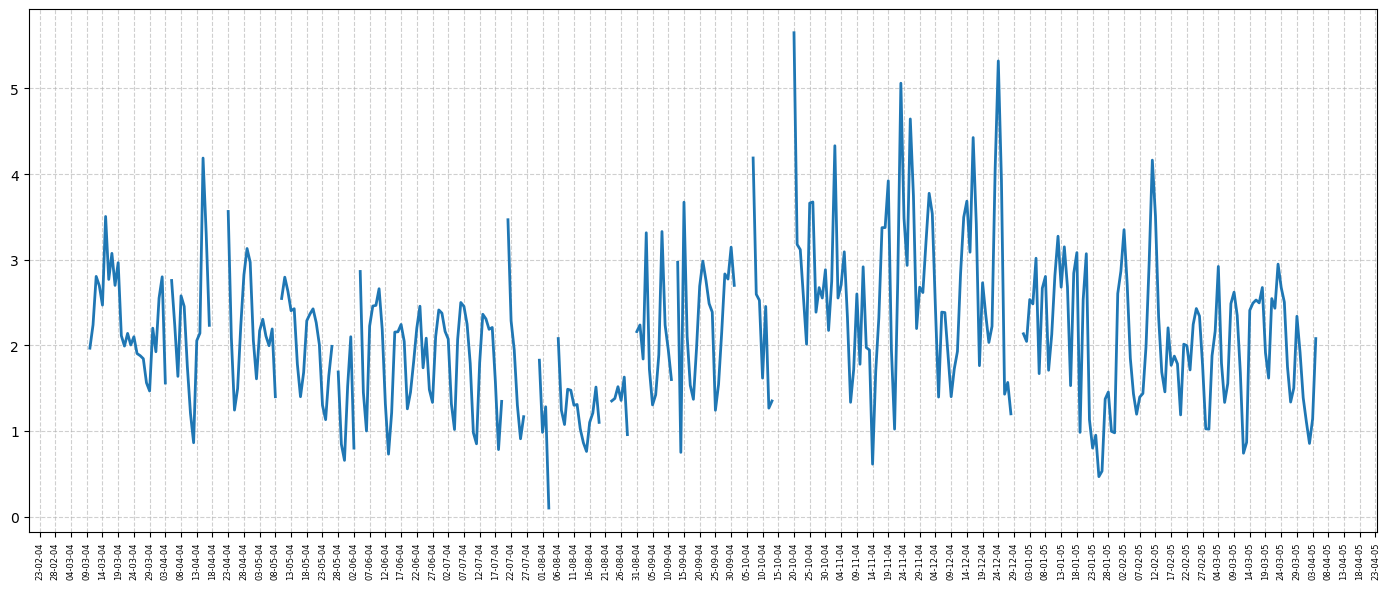

In [53]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

plot_df = nan_df[["Date", "CO(GT)"]].copy().set_index("Date")
plot_df = plot_df.resample("D").mean()
fig, ax = plt.subplots(figsize=(14, 6), layout="tight")
ax.plot(plot_df.index, plot_df.values, linewidth=2, label="Plot")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%m-%y"))
plt.xticks(rotation=90, fontsize=6)
ax.grid(True, linestyle="--", alpha=0.6)

# Data Processing

- Dropped rows/cols: 114 rows (earlier) + 2 unnamed columns (earlier)


In [54]:
DEFAULT_SPLIT = [0.7, 0.15, 0.15]


def split_dataset(
    features: np.ndarray,
    target: np.ndarray,
    split: list | None = None,
):
    ndarray_split = np.array(split)

    if split is None:
        ndarray_split = np.array(DEFAULT_SPLIT)
    elif ndarray_split.shape != (3,):
        raise ValueError("Shape of split array must be (3,)")
    elif ndarray_split.sum() != 1 or ndarray_split.sum != 100:
        raise ValueError("Split percentage must sum to 1 or 100%")

    if ndarray_split.sum() == 100:
        ndarray_split /= 100

    if len(features) != len(target):
        raise ValueError("Lengths of feature set and target set are mismatch")

    total_entries = len(features)
    cumsum_split = np.cumsum(ndarray_split)

    train_stop_index = int(cumsum_split[0] * total_entries)
    val_stop_index = int(cumsum_split[1] * total_entries)

    train_x = features[:train_stop_index]
    train_y = target[:train_stop_index]

    validate_x = features[train_stop_index:val_stop_index]
    validate_y = target[train_stop_index:val_stop_index]

    test_x = features[val_stop_index:]
    test_y = target[val_stop_index:]

    return ((train_x, train_y), (validate_x, validate_y), (test_x, test_y))

In [55]:
# Splitting

working_df = nan_df.drop(columns=["Date", "Time"])
working_df = working_df.interpolate("linear")

target = "CO(GT)"
features = working_df.columns.drop(
    ["NMHC(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)", target]
).to_list()

df_x = working_df[features]
df_y = working_df[[target]]

((train_x, train_y), (validate_x, validate_y), (test_x, test_y)) = split_dataset(
    features=df_x, target=df_y
)
print(train_x.shape)

(6549, 8)


In [56]:
# Normalizing

from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

train_x = scaler_x.fit_transform(train_x)
train_y = scaler_y.fit_transform(train_y)

validate_x = scaler_x.transform(validate_x)
validate_y = scaler_y.transform(validate_y)

test_x = scaler_x.transform(test_x)
test_y = scaler_y.transform(test_y)

In [57]:
# Sliding window

from keras.utils import timeseries_dataset_from_array

TIME_STEPS = 24
BATCH_SIZE = 32


train_dataset = timeseries_dataset_from_array(
    data=train_x,
    targets=train_y[TIME_STEPS:],
    sequence_length=TIME_STEPS,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

validate_dataset = timeseries_dataset_from_array(
    data=validate_x,
    targets=validate_y[TIME_STEPS:],
    sequence_length=TIME_STEPS,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_dataset = timeseries_dataset_from_array(
    data=test_x,
    targets=test_y[TIME_STEPS:],
    sequence_length=TIME_STEPS,
    sequence_stride=1,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

# Models


In [82]:
UNITS = 32
ACTIVATION = "relu"
DROPOUT = 0.2

In [83]:
# RNN

from keras.layers import Dense, Dropout, SimpleRNN
from keras.models import Sequential

rnn = Sequential(
    [
        SimpleRNN(
            units=UNITS,
            activation=ACTIVATION,
            input_shape=(TIME_STEPS, train_x.shape[1]),
            recurrent_dropout=DROPOUT,
        ),
        Dropout(DROPOUT),
        Dense(1, kernel_regularizer="l2"),
    ]
)

rnn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

In [84]:
# LSTM

from keras.layers import LSTM

lstm = Sequential(
    [
        LSTM(
            units=UNITS,
            activation=ACTIVATION,
            input_shape=(TIME_STEPS, train_x.shape[1]),
            recurrent_dropout=DROPOUT,
        ),
        Dropout(DROPOUT),
        Dense(1, kernel_regularizer="l2"),
    ]
)

lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"],
)

# Training


In [85]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

EPOCHS = 20


def create_callback(model_type: str):
    if model_type.lower() != "rnn" and model_type.lower() != "lstm":
        raise ValueError("Unknown model type")

    return [
        ModelCheckpoint(
            filepath=f"models/{model_type.lower()}.keras",
            mode="min",
            save_best_only=True,
        ),
        EarlyStopping(patience=20, verbose=1, restore_best_weights=True),
    ]

In [86]:
# RNN training

rnn_history = rnn.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validate_dataset,
    shuffle=False,
    verbose=1,
    callbacks=create_callback("RNN"),
)

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0636 - mae: 0.1498 - val_loss: 0.0260 - val_mae: 0.0940
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0231 - mae: 0.0872 - val_loss: 0.0181 - val_mae: 0.0768
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0166 - mae: 0.0753 - val_loss: 0.0153 - val_mae: 0.0759
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0133 - mae: 0.0711 - val_loss: 0.0134 - val_mae: 0.0749
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0117 - mae: 0.0692 - val_loss: 0.0122 - val_mae: 0.0745
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0107 - mae: 0.0683 - val_loss: 0.0115 - val_mae: 0.0741
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0098 - mae: 0.0674 - val_loss: 0.0111 - val_mae: 0.0748
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0092 - mae: 0.0665 - val_loss: 0.0106 - val_mae: 0.0738
Epoch 9/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - lo

In [87]:
# LSTM training

lstm_history = lstm.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validate_dataset,
    shuffle=False,
    verbose=1,
    callbacks=create_callback("LSTM"),
)

Epoch 1/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - loss: 0.0307 - mae: 0.0993 - val_loss: 0.0210 - val_mae: 0.0884
Epoch 2/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0164 - mae: 0.0789 - val_loss: 0.0157 - val_mae: 0.0845
Epoch 3/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0129 - mae: 0.0763 - val_loss: 0.0139 - val_mae: 0.0842
Epoch 4/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0114 - mae: 0.0745 - val_loss: 0.0128 - val_mae: 0.0829
Epoch 5/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0103 - mae: 0.0721 - val_loss: 0.0123 - val_mae: 0.0827
Epoch 6/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - loss: 0.0098 - mae: 0.0712 - val_loss: 0.0118 - val_mae: 0.0817
Epoch 7/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.0094 - mae: 0.0703 - val_loss: 0.0113 - val_mae: 0.0806
Epoch 8/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0092 - mae: 0.0698 - val_loss: 0.0112 - val_mae: 0.0809
Epoch 9/20
204/204 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/

# Evaluation


In [88]:
def get_predicted_metrics(model: Sequential):
    test_predicted = model.evaluate(test_dataset)

    mse, mae = test_predicted

    return (mse, mae)


In [89]:
# RNN evaluation
rnn_mse, rnn_mae = get_predicted_metrics(rnn)

print(f"RNN MSE: {rnn_mse:.4f}")
print(f"RNN MAE: {rnn_mae:.4f}")

rnn_predicted_y_scaled = rnn.predict(test_dataset)
rnn_predicted_y = scaler_y.inverse_transform(rnn_predicted_y_scaled)

true_y_scaled = np.concatenate([y for x, y in test_dataset], axis=0)
true_y = scaler_y.inverse_transform(true_y_scaled)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0074 - mae: 0.0691
RNN MSE: 0.0074
RNN MAE: 0.0691
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [90]:
# LSTM evaluation

lstm_mse, lstm_mae = get_predicted_metrics(lstm)

print(f"LSTM MSE: {lstm_mse:.4f}")
print(f"LSTM MAE: {lstm_mae:.4f}")

lstm_predicted_y_scaled = lstm.predict(test_dataset)
lstm_predicted_y = scaler_y.inverse_transform(lstm_predicted_y_scaled)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0079 - mae: 0.0732
LSTM MSE: 0.0079
LSTM MAE: 0.0732
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [91]:
from keras.callbacks import History


def generate_loss_plots(
    model_history: History, model_type: str, figsize: tuple = (20, 6)
):
    _, axes = plt.subplots(1, 2, figsize=figsize)

    axes[0].plot(
        model_history.history["loss"],
        label=f"{model_type} Train MSE",
        color="red",
        linewidth=2,
    )

    axes[0].plot(
        model_history.history["val_loss"],
        label=f"{model_type} Validation MSE",
        color="orange",
        linewidth=2,
        linestyle=":",
    )

    axes[1].plot(
        model_history.history["mae"],
        label=f"{model_type} Train MAE",
        color="purple",
        linewidth=2,
    )

    axes[1].plot(
        model_history.history["val_mae"],
        label=f"{model_type} Validation MAE",
        color="blue",
        linewidth=2,
        linestyle=":",
    )

    axes[0].set_title("Training vs. Validation Loss", fontsize=14)
    axes[1].set_title("Training vs. Validation MAE", fontsize=14)
    axes[0].set_xlabel("Epochs", fontsize=12)
    axes[1].set_xlabel("Epochs", fontsize=12)
    axes[0].legend(loc="upper right")
    axes[1].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


def generate_CO_values_plots(
    predicted_y: np.ndarray,
    model_type: str,
    samples: int = 300,
    figsize: tuple = (20, 6),
):
    _, axes = plt.subplots(1, 1, figsize=figsize)

    axes.plot(true_y[:samples], label="True CO(GT)", color="green", linewidth=2)
    axes.plot(
        predicted_y[:samples],
        label="Predicted CO(GT)",
        color="blue",
        linewidth=2,
        alpha=0.4,
        linestyle="--",
    )

    axes.set_title(
        f"{model_type} True vs. Predicted CO(GT)\nSamples: First {samples}h",
        fontsize=14,
    )
    axes.set_xlabel("Time steps", fontsize=12)
    axes.legend(loc="upper right")
    axes.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

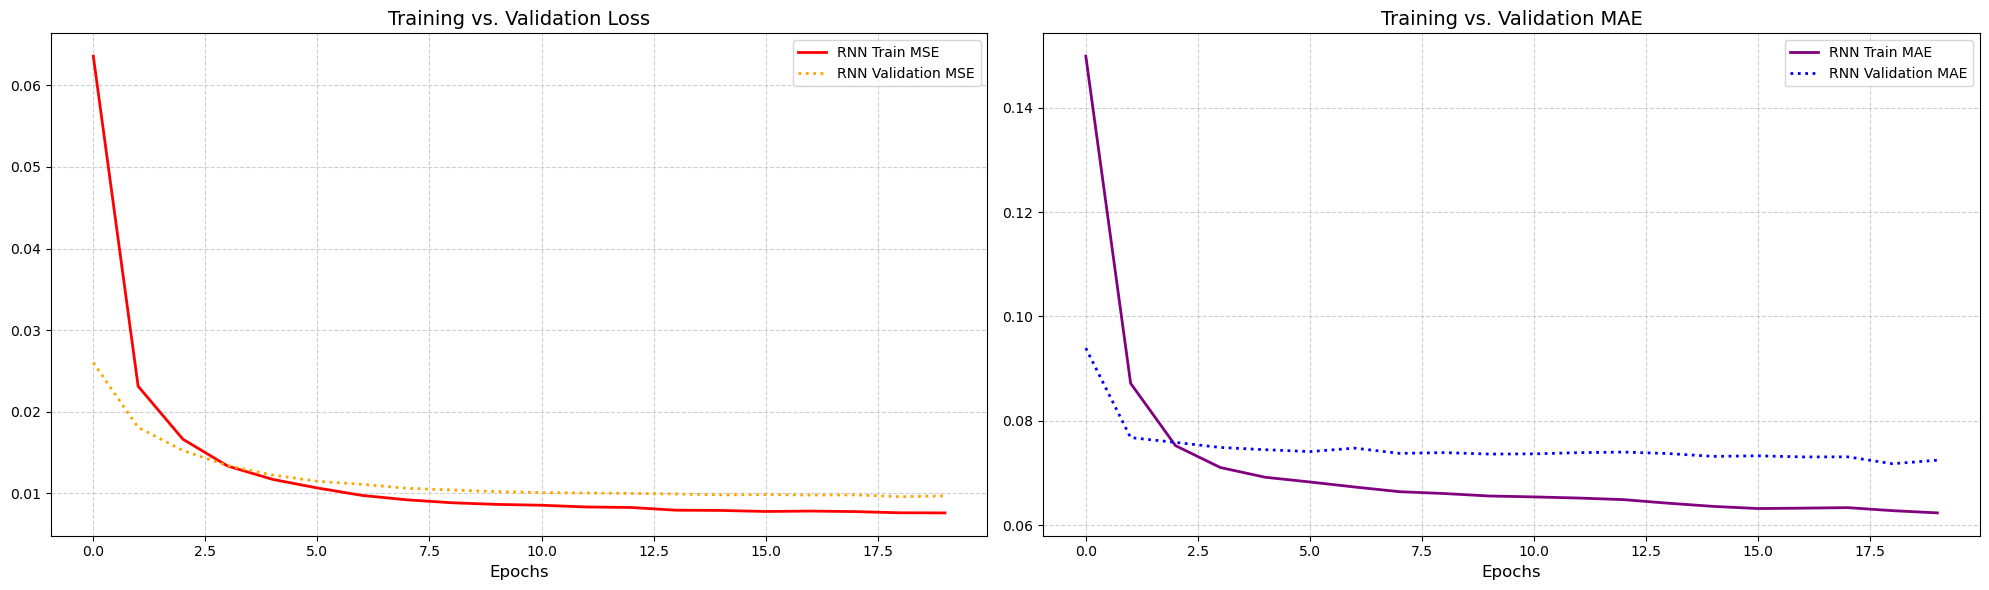

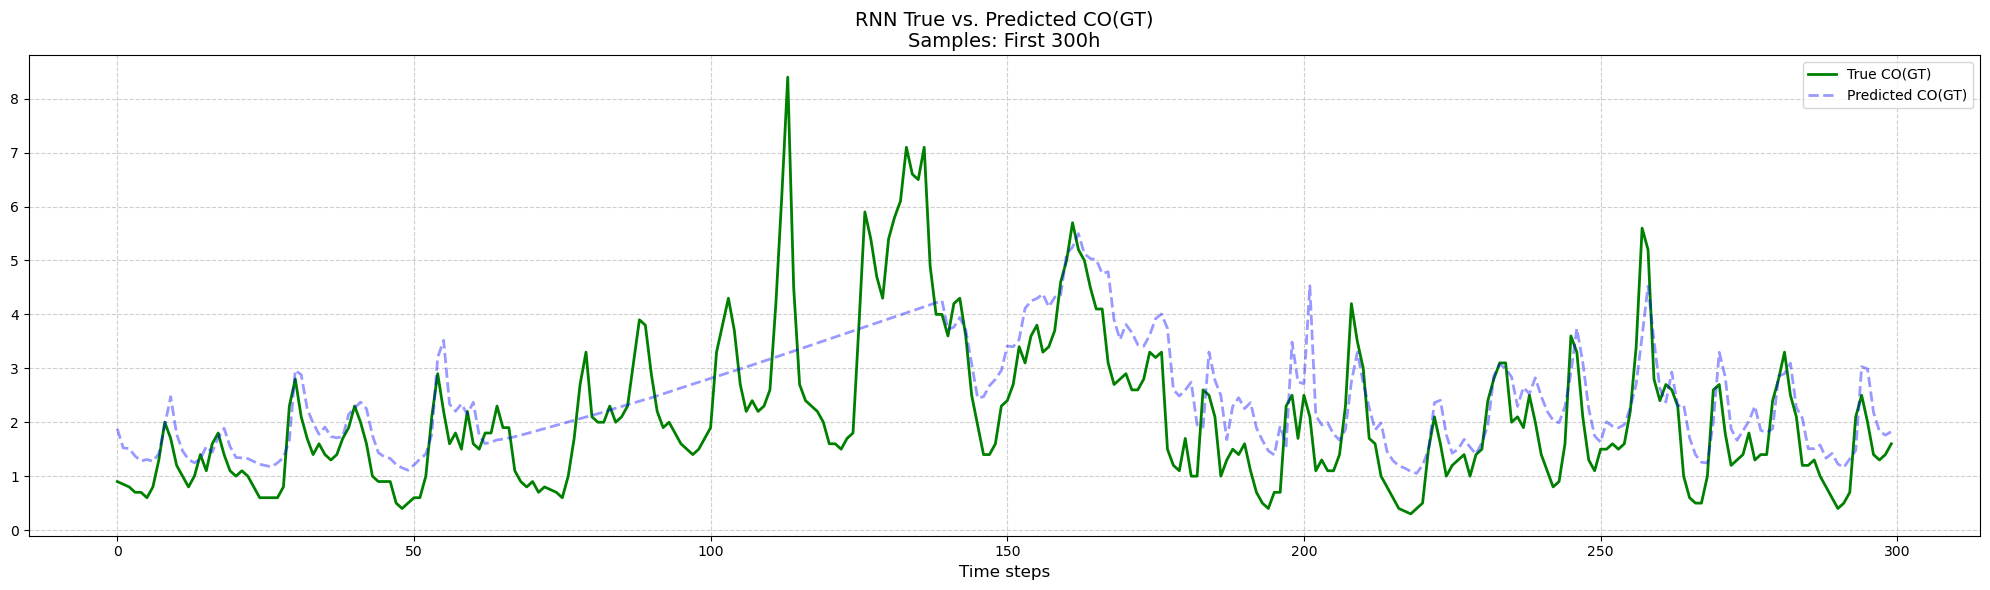

In [92]:
# RNN plots

generate_loss_plots(rnn_history, model_type="RNN")
generate_CO_values_plots(rnn_predicted_y, model_type="RNN")

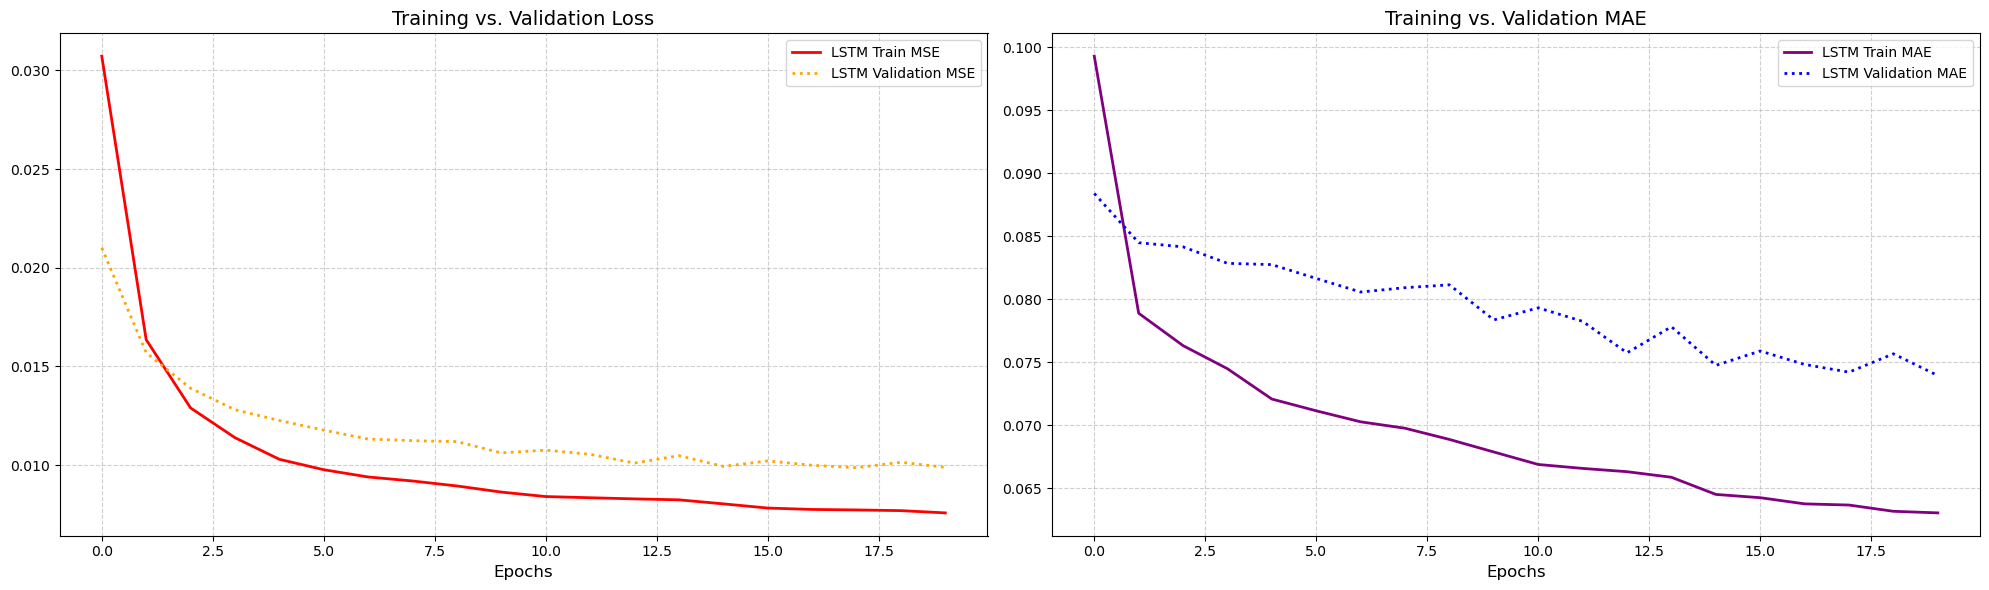

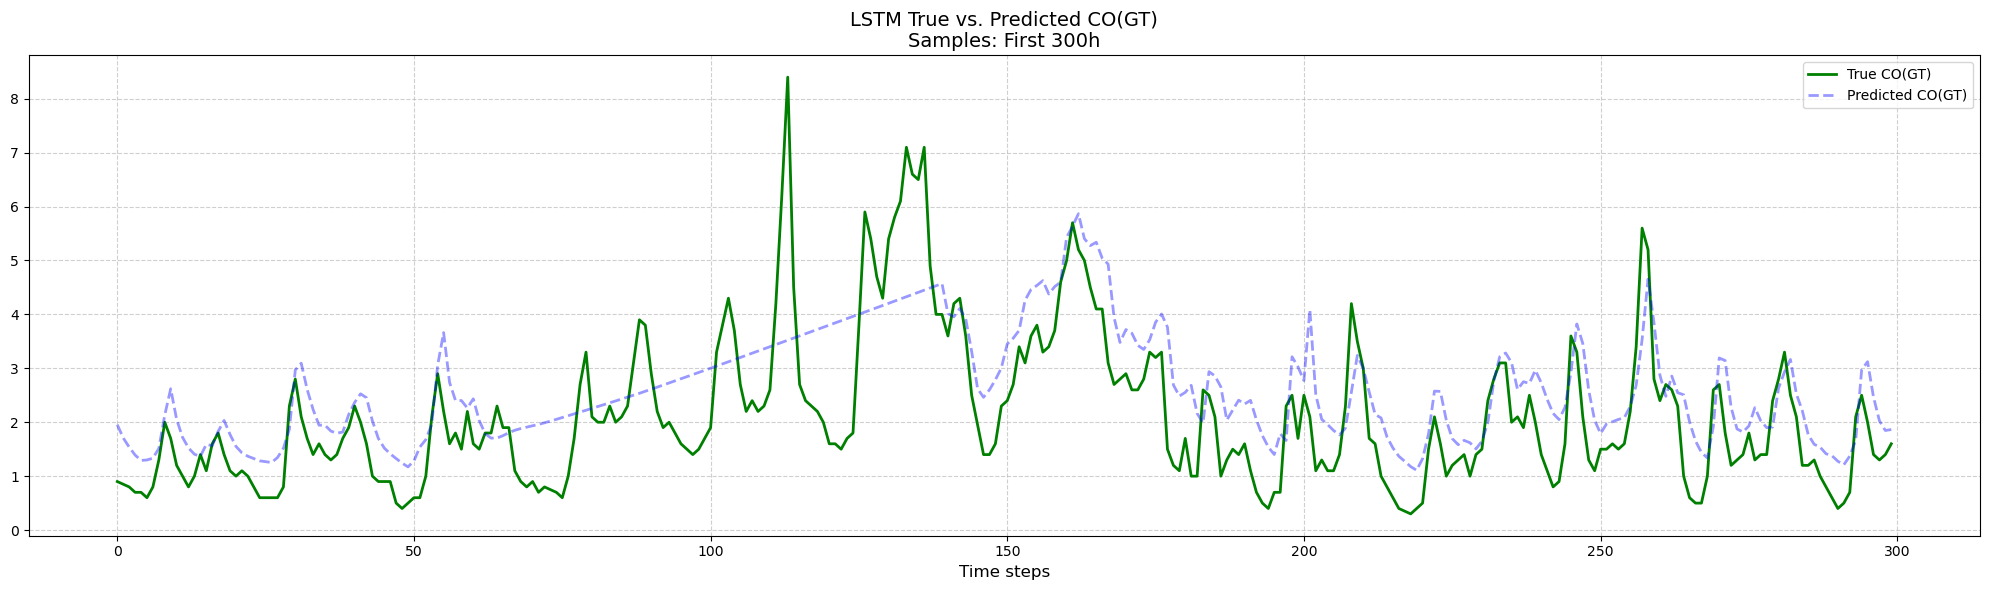

In [93]:
# LSTM plots

generate_loss_plots(lstm_history, model_type="LSTM")
generate_CO_values_plots(lstm_predicted_y, model_type="LSTM")